# CMIP6 Models - Create and analyze trends across the Winter stats: 1961 - 2025+

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess as  sm_lowess
import pwlf #piecewise linear fits

# for confidence bands on lowess
import scipy.interpolate

# to get rid of runtime warnings when OLS fits hit a divide by zero - handled by setting R2 and p-vals appropriately
import warnings
warnings.filterwarnings('ignore')

## * CanESM5

### Build and write out the full 1990-2099 data set as single file

### Load LSM for filtering

In [2]:
file_path = '../../../../Data/CMIP6/CanESM5/FixedCoords/sftlf_fx_CanESM5_historical_r1i1p1f1_gn.nc'
ds_lsm = xr.open_dataset(file_path)
ds_lsm

<xarray.Dataset> Size: 37kB
Dimensions:   (lat: 64, bnds: 2, lon: 128)
Coordinates:
  * lat       (lat) float64 512B -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
  * lon       (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
    type      |S4 4B ...
Dimensions without coordinates: bnds
Data variables:
    lat_bnds  (lat, bnds) float64 1kB ...
    lon_bnds  (lon, bnds) float64 2kB ...
    sftlf     (lat, lon) float32 33kB ...
Attributes: (12/53)
    CCCma_model_hash:            3dedf95315d603326fde4f5340dc0519d80d10c0
    CCCma_parent_runid:          rc3-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-his01
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1850:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/90f93a05-357c-4ea2-b61f-bf24187...
    variable_id:                 sftlf
    variant_label:               r1i1p1f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0

#### Map of the landfrac / landsea mask for CanESM5

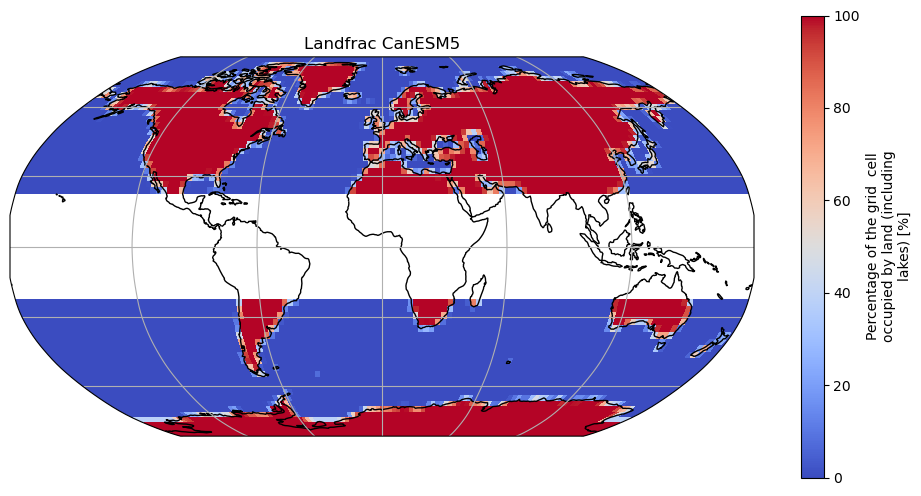

In [3]:
# Global summer length for the year
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

ds_lsm.sftlf.where((ds_lsm.lat <= -23.5) | (ds_lsm.lat >= 23.5)).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=50,
    #vmax=150, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Landfrac CanESM5")#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

### Merge all the years and include the landsea mask

In [5]:
%%time

# start with one year and add a coordinate for the year
year = 1990
input_path = '../../../../Data/CMIP6/CanESM5/Winters-SSP2-45/'+str(year)+'_CanESM5_winter_stats.nc'
ds = xr.open_dataset(input_path)
ds = ds.merge(ds_lsm)
ds = ds.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(1991,2100,1)

for year in input_years:
    input_path = '../../../../Data/CMIP6/CanESM5/Winters-SSP2-45/'+str(year)+'_CanESM5_winter_stats.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.merge(ds_lsm)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds = ds.merge(ds_i)

ds

CPU times: user 2.19 s, sys: 1.11 s, total: 3.3 s
Wall time: 3.45 s


<xarray.Dataset> Size: 62MB
Dimensions:         (lat: 64, lon: 128, time: 110, bnds: 2)
Coordinates:
  * lat             (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon             (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
  * time            (time) datetime64[us] 880B 1990-01-01 ... 2099-01-01
    type            |S4 4B b'land'
Dimensions without coordinates: bnds
Data variables:
    WinterStart     (time, lat, lon) float64 7MB 238.0 237.0 236.0 ... 0.0 0.0
    WinterEnd       (time, lat, lon) float64 7MB 259.0 260.0 260.0 ... 0.0 0.0
    WinterTmax      (time, lat, lon) float64 7MB 239.0 238.0 238.0 ... 41.0 41.0
    WinterCold      (time, lat, lon) float64 7MB 72.7 84.67 83.93 ... 0.0 0.0
    WinterLength    (time, lat, lon) float64 7MB 22.0 24.0 25.0 ... 0.0 0.0 0.0
    WinterlikeDays  (time, lat, lon) float64 7MB 85.0 84.0 83.0 ... 0.0 0.0 0.0
    WinterRMSE      (time, lat, lon) float64 7MB 6.369 6.33 ... 1.184 1.197
    WinterMeanT     (time, lat, lon) float64 7MB 221.5 222.3 223.5 ... 0.0 0.0
    lat_bnds        (time, lat, bnds) float64 113kB -90.0 -86.58 ... 86.58 90.0
    lon_bnds        (time, lon, bnds) float64 225kB 178.6 181.4 ... 175.8 178.6
    sftlf           (time, lat, lon) float32 4MB 100.0 100.0 100.0 ... 0.0 0.0

### Map of winter length

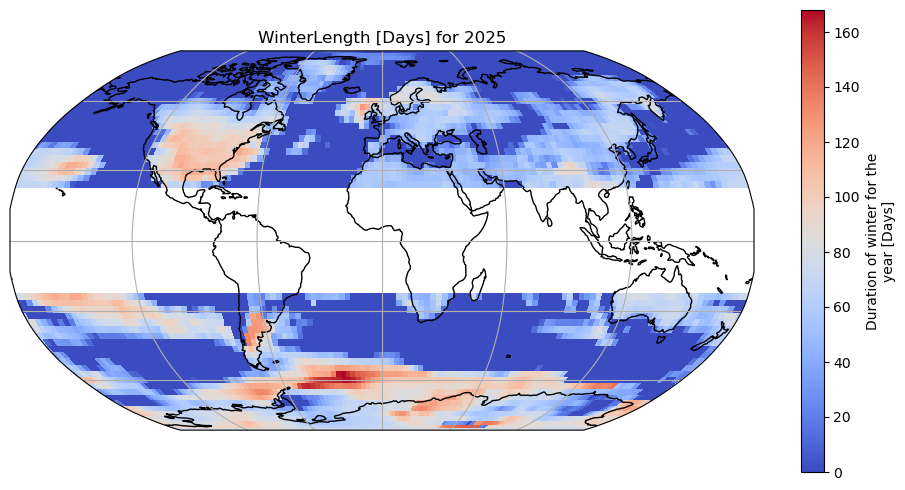

CPU times: user 486 ms, sys: 49 ms, total: 535 ms
Wall time: 591 ms


In [7]:
%%time
input_year=2025

# Global summer length for the year
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

ds.WinterLength.sel(time=str(input_year)).where((ds.lat <= -23.5) | (ds.lat >= 23.5)).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=50,
    #vmax=150, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("WinterLength [Days] for "+str(input_year))#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

#### Same but for land only

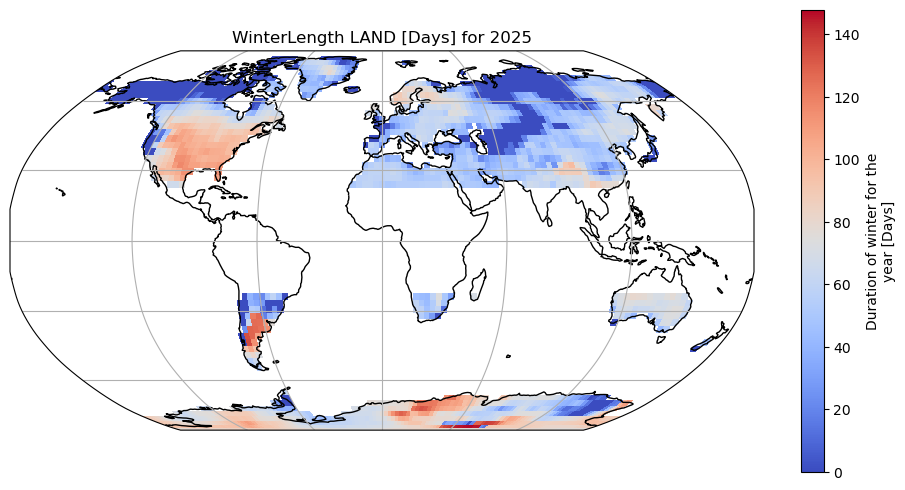

CPU times: user 336 ms, sys: 27.4 ms, total: 363 ms
Wall time: 366 ms


In [12]:
%%time
input_year=2025

# Global summer length for the year
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

ds.WinterLength.sel(time=str(input_year)).where(((ds.lat <= -23.5) | (ds.lat >= 23.5)) & (ds.sftlf >= 50)).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=50,
    #vmax=150, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("WinterLength LAND [Days] for "+str(input_year))#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

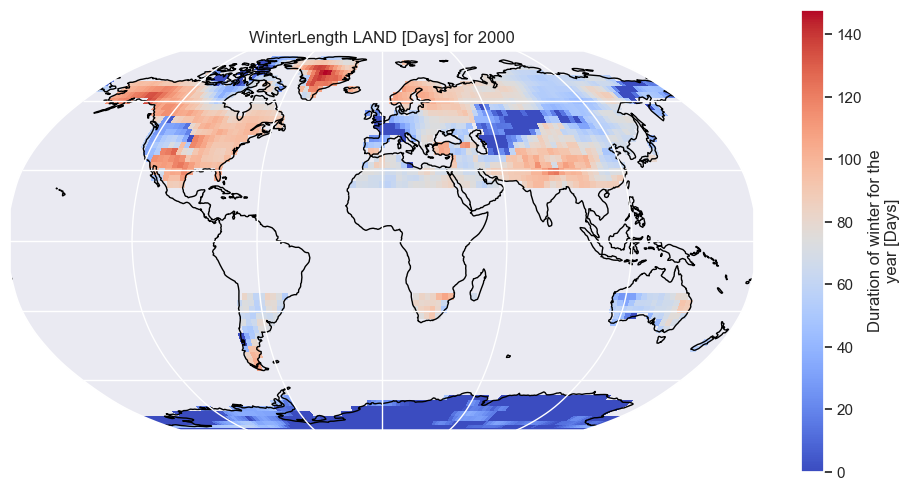

CPU times: user 349 ms, sys: 12.8 ms, total: 362 ms
Wall time: 362 ms


In [29]:
%%time
input_year=2000

# Global summer length for the year
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

ds.WinterLength.sel(time=str(input_year)).where(((ds.lat <= -23.5) | (ds.lat >= 23.5)) & (ds.sftlf >= 50)).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=50,
    #vmax=150, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("WinterLength LAND [Days] for "+str(input_year))#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

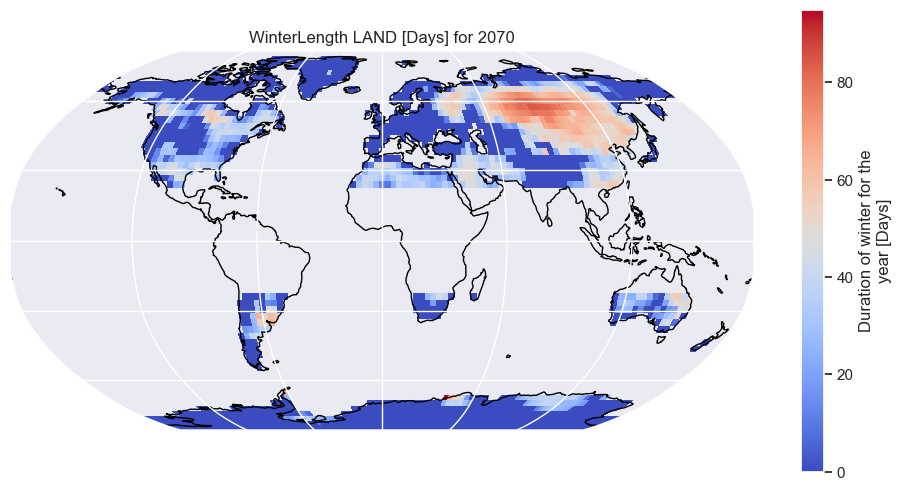

CPU times: user 342 ms, sys: 20.2 ms, total: 363 ms
Wall time: 362 ms


In [30]:
%%time
input_year=2070

# Global summer length for the year
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

ds.WinterLength.sel(time=str(input_year)).where(((ds.lat <= -23.5) | (ds.lat >= 23.5)) & (ds.sftlf >= 50)).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=50,
    #vmax=150, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("WinterLength LAND [Days] for "+str(input_year))#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

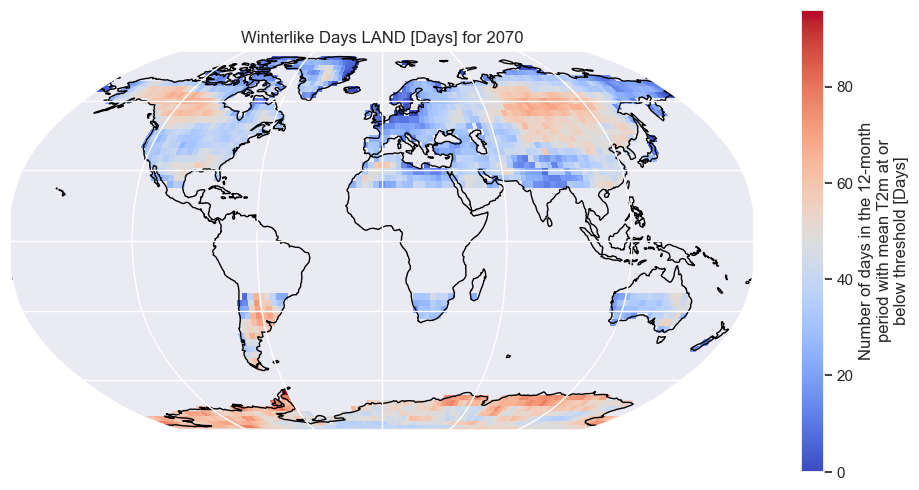

CPU times: user 364 ms, sys: 14.7 ms, total: 379 ms
Wall time: 379 ms


In [31]:
%%time
input_year=2070

# Global summer length for the year
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

ds.WinterlikeDays.sel(time=str(input_year)).where(((ds.lat <= -23.5) | (ds.lat >= 23.5)) & (ds.sftlf >= 50)).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=50,
    #vmax=150, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Winterlike Days LAND [Days] for "+str(input_year))#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

### Write out dataset

In [8]:
# write out complete dataset 
output_path = '../../../../Data/CMIP6/CanESM5/Winters-SSP2-45/1990-2099_ALL_winter_stats.nc'
ds.to_netcdf(output_path)



### *** Jump here now - reload dataset

In [16]:
ds_canesm5 = xr.open_dataset('../../../../Data/CMIP6/CanESM5/Winters-SSP2-45/1990-2099_ALL_winter_stats.nc')
ds_canesm5 = ds_canesm5.drop_vars(["lat_bnds", "lon_bnds"])
ds_canesm5

<xarray.Dataset> Size: 61MB
Dimensions:         (time: 110, lat: 64, lon: 128)
Coordinates:
  * time            (time) datetime64[ns] 880B 1990-01-01 ... 2099-01-01
  * lat             (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon             (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
    type            |S4 4B ...
Data variables:
    WinterStart     (time, lat, lon) float64 7MB ...
    WinterEnd       (time, lat, lon) float64 7MB ...
    WinterTmax      (time, lat, lon) float64 7MB ...
    WinterCold      (time, lat, lon) float64 7MB ...
    WinterLength    (time, lat, lon) float64 7MB ...
    WinterlikeDays  (time, lat, lon) float64 7MB ...
    WinterRMSE      (time, lat, lon) float64 7MB ...
    WinterMeanT     (time, lat, lon) float64 7MB ...
    sftlf           (time, lat, lon) float32 4MB ...

In [17]:
# find weights (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(ds_canesm5.lat))
weights.name = "weights"

In [18]:
# latitude & longitude ranges for NH and SH midlatitudes so they will be easy to adjust
nh_min = 23.5
nh_max = 70
sh_min = -23.5
sh_max = -70

### Weighted mean metrics for NH and SH

In [19]:
%%time

nh_full_canesm5 = ds_canesm5.where((ds_canesm5.lat >= nh_min) & (ds_canesm5.lat <= nh_max)).weighted(weights).mean(dim=['lat','lon'])
sh_full_canesm5 = ds_canesm5.where((ds_canesm5.lat >= sh_max) & (ds_canesm5.lat <= sh_min)).weighted(weights).mean(dim=['lat','lon'])
nh_full_land_canesm5 = ds_canesm5.where((ds_canesm5.lat >= nh_min) & (ds_canesm5.lat <= nh_max) & (ds_canesm5.sftlf >= 50)).weighted(weights).mean(dim=['lat','lon'])
sh_full_land_canesm5 = ds_canesm5.where((ds_canesm5.lat >= sh_max) & (ds_canesm5.lat <= sh_min) & (ds_canesm5.sftlf >= 50)).weighted(weights).mean(dim=['lat','lon'])

CPU times: user 169 ms, sys: 104 ms, total: 273 ms
Wall time: 276 ms


In [20]:
plot_vars = list(ds_canesm5.data_vars)
plot_vars

['WinterStart',
 'WinterEnd',
 'WinterTmax',
 'WinterCold',
 'WinterLength',
 'WinterlikeDays',
 'WinterRMSE',
 'WinterMeanT',
 'sftlf']

### Set plot vars

In [21]:
plot_vars = list(ds_canesm5.data_vars)
remove_me = {'WinterRMSE','sftlf','WinterMeanT'}
plot_vars = [item for item in plot_vars if item not in remove_me]
plot_vars

['WinterStart',
 'WinterEnd',
 'WinterTmax',
 'WinterCold',
 'WinterLength',
 'WinterlikeDays']

In [22]:
# plot properties so I can more easily tweak them
s = 18
lw = 4
alpha = 0.6
fs = 20

sns.set_theme(style="darkgrid")

### Plots with linear fits 1990-2099

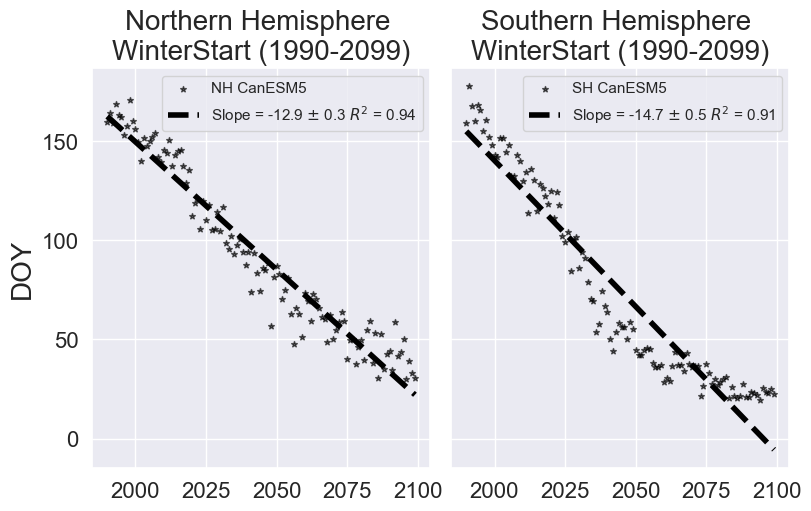

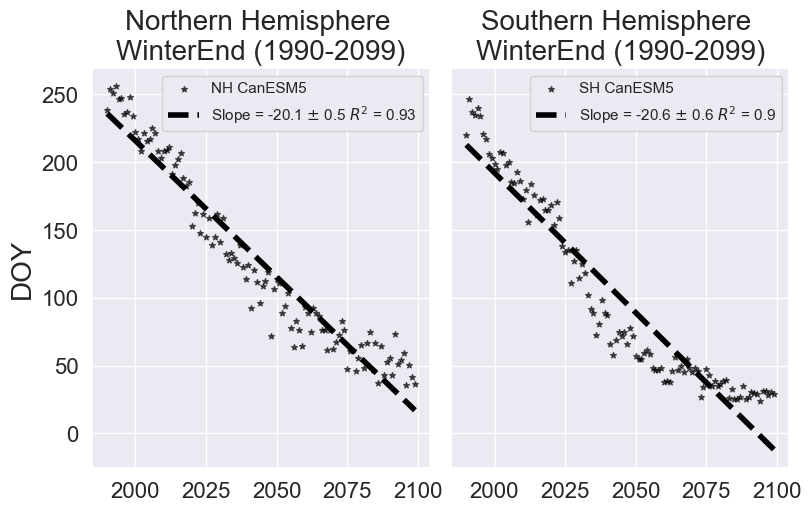

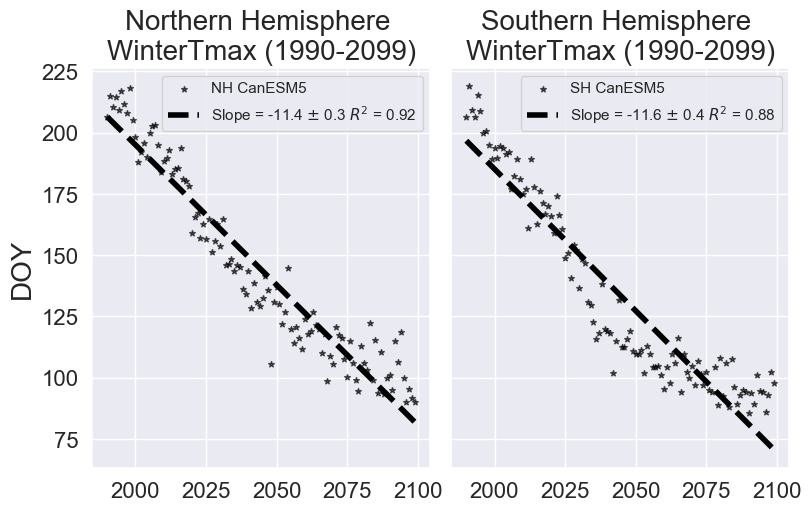

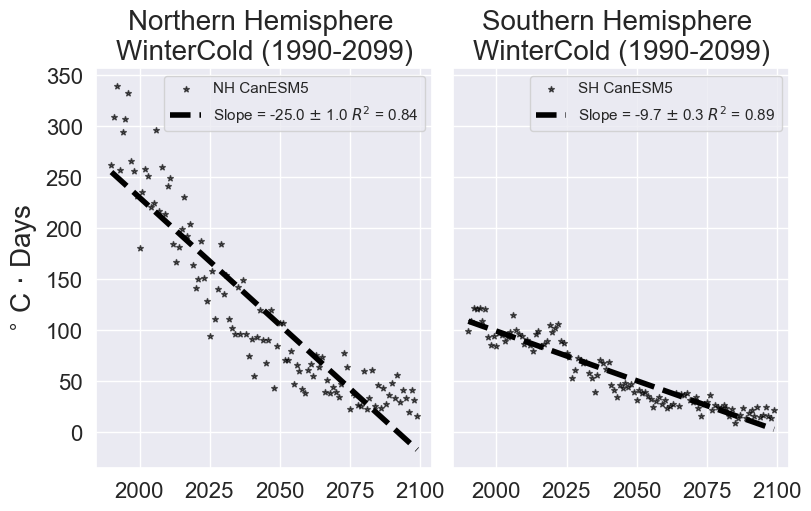

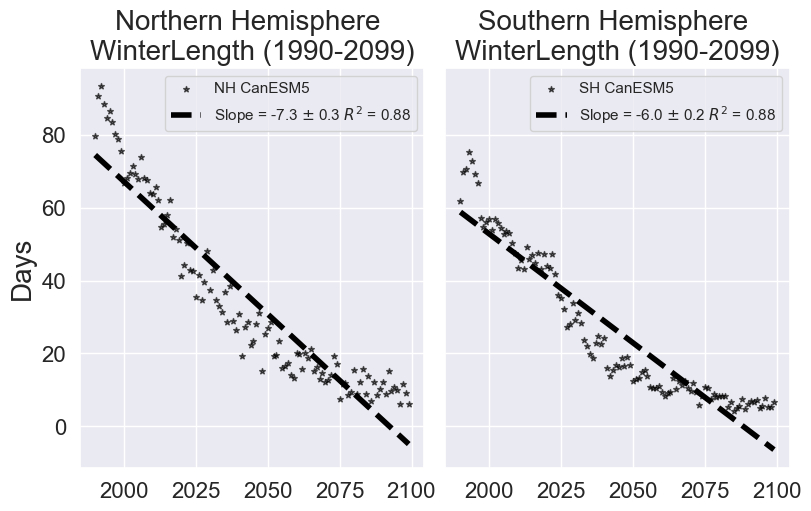

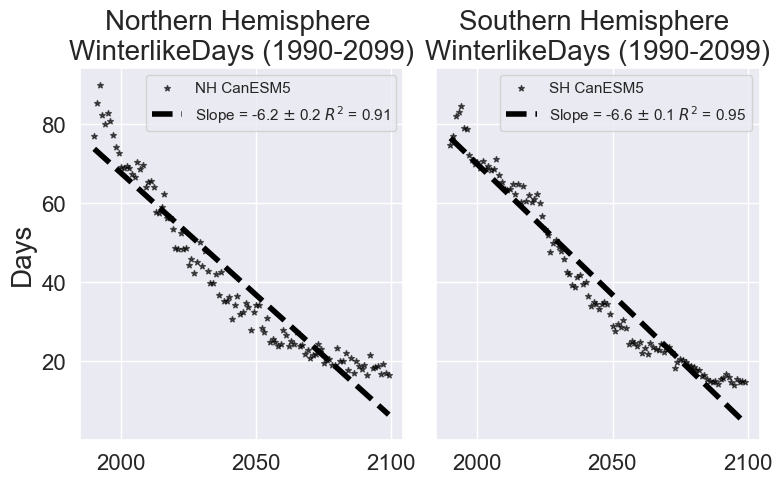

CPU times: user 631 ms, sys: 80.4 ms, total: 712 ms
Wall time: 764 ms


In [26]:
%%time

# takes XX sec

# loop through all plot variables
for i,v in enumerate(plot_vars):

    # create blank fig
    fig = plt.figure(figsize = (8,5), layout='constrained')

    # Analysis time period NH
    ax3 = fig.add_subplot(1,2,1)

    # linear fits for slope
    x = nh_full_canesm5.time.dt.year.values
    y = nh_full_canesm5[v].values
    coefs, V = np.polyfit(x, y, 1, cov=True)
    poly = np.poly1d(coefs)
    slope = 10 * np.round(coefs[0],2) # per decade
    slope_sd = 10 * np.round(np.sqrt(V[0][0]),2) # per decade
    # add in R^2 and RMSE
    ymean = np.mean(y)
    ss_total = np.sum((y - ymean)**2)
    ss_res = np.sum((y - poly(x))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax3.scatter(x, y, label="NH CanESM5", marker='*', facecolors='black', edgecolors='black', s=s, alpha=alpha)
    ax3.plot(x, poly(x), linestyle="dashed", linewidth=lw, color='black',
         label="Slope = "+str(np.round(slope,2))+" $\pm$ "+str(np.round(slope_sd,2))+" $R^2$ = "+str(r_squared))
    ax3.set_title("Northern Hemisphere \n" + v + " (1990-2099)", fontsize = fs)
    # Annotation - units in per decade
    # ann_y = (ax3.get_yticks())[-3]+8
    # ann_x = np.mean(ax3.get_xticks())-5
    # # plot shows mean slope across all surface types for clarity
    # mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope**2)/np.sqrt(3) * 10 # to get days per decade
    # if (slope_ocean < 0):
    #     mean_slope = mean_slope * -1
    # ax3.text(ann_x, ann_y, 
    #          ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=16)
    if i < 3:
        ylabel = 'DOY'
    elif i == 3:
        ylabel = '$^{\circ}$ C $\cdot$ Days'
    #elif i == 2:
        #ylabel = '$^\circ$C'
    else:
        ylabel = 'Days'
    ax3.set_ylabel(ylabel, fontsize=fs)
    ax3.legend(loc='best')

    
    # Analysis time period SH
    ax4 = fig.add_subplot(1,2,2, sharey=ax3)

    # linear fits for slope
    x = sh_full_canesm5.time.dt.year.values
    y = sh_full_canesm5[v].values
    coefs, V = np.polyfit(x, y, 1, cov=True)
    poly = np.poly1d(coefs)
    slope = 10.0 * np.round(coefs[0],2) # per decade
    slope_sd = 10.0 * np.round(np.sqrt(V[0][0]),2) # per decade
    # add in R^2 and RMSE
    ymean = np.mean(y)
    ss_total = np.sum((y - ymean)**2)
    ss_res = np.sum((y - poly(x))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax4.scatter(x, y, label="SH CanESM5", marker='*', facecolors='black', edgecolors='black', s=s, alpha=alpha)
    ax4.plot(x, poly(x), linestyle="dashed", linewidth=lw, color='black',
         label="Slope = "+str(np.round(slope,2))+" $\pm$ "+str(np.round(slope_sd,2))+" $R^2$ = "+str(r_squared))
    ax4.set_title("Southern Hemisphere \n" + v + " (1990-2099)", fontsize = fs)
    # Annotation - units in per decade
    # ann_y = (ax4.get_yticks())[-3]+8
    # ann_x = np.mean(ax4.get_xticks())-5
    #     # plot shows mean slope across all surface types for clarity
    # mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope**2)/np.sqrt(3) * 10 # to get days per decade
    # if (slope_ocean < 0):
    #     mean_slope = mean_slope * -1
    # ax4.text(ann_x, ann_y, 
    #          ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')
    
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=6, labelleft=False)
    ax4.legend(loc='best')


plt.tight_layout()
plt.show()

### Plots with linear fits LAND only

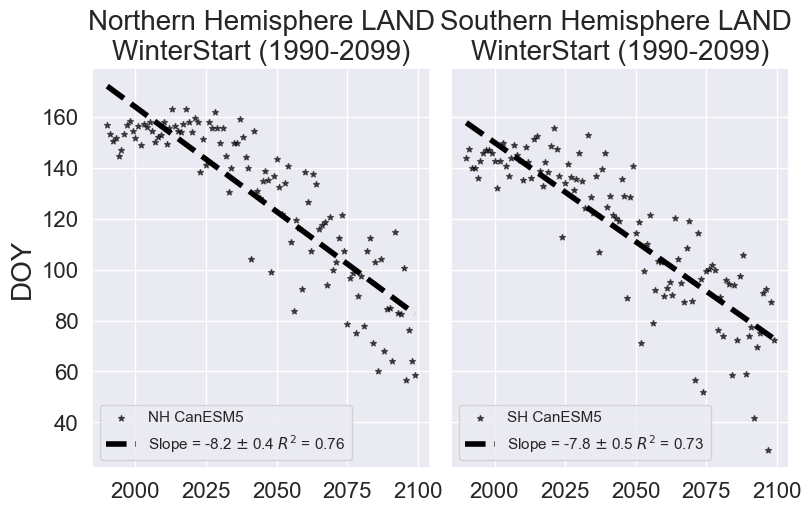

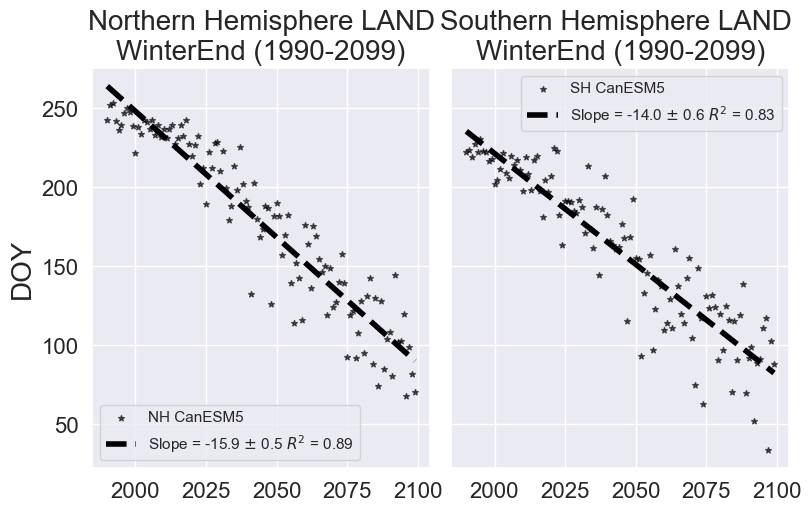

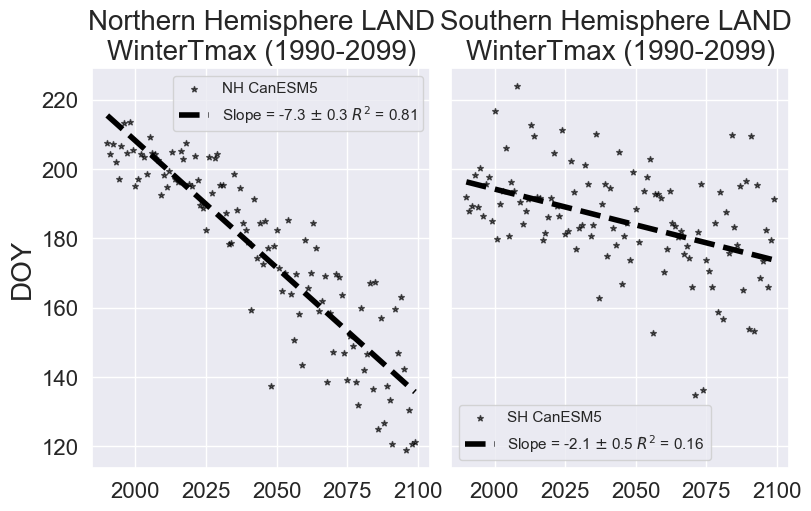

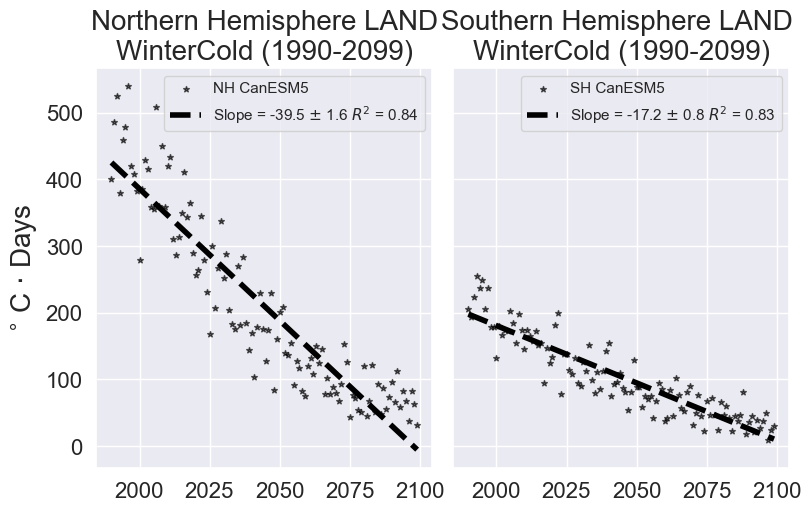

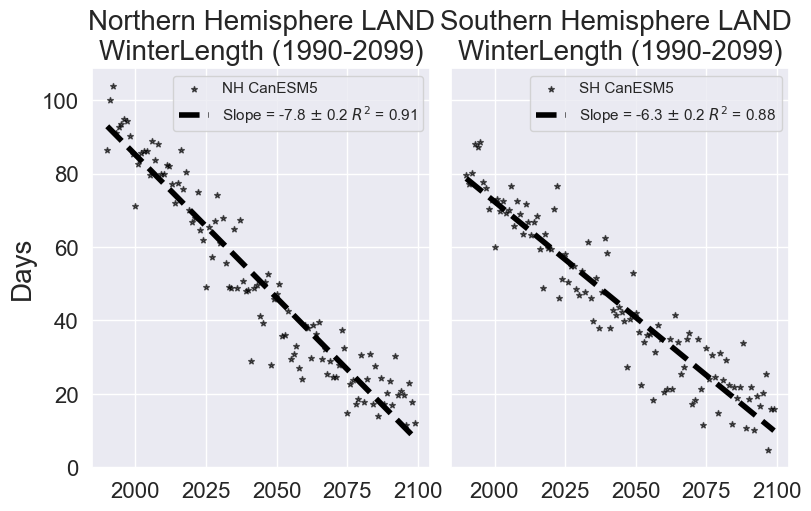

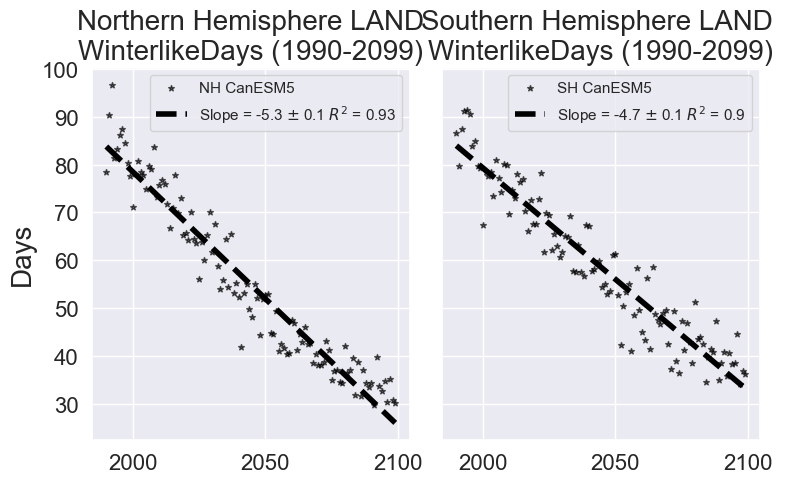

CPU times: user 697 ms, sys: 90.1 ms, total: 787 ms
Wall time: 843 ms


In [27]:
%%time

# takes XX sec

# loop through all plot variables
for i,v in enumerate(plot_vars):

    # create blank fig
    fig = plt.figure(figsize = (8,5), layout='constrained')

    # Analysis time period NH
    ax3 = fig.add_subplot(1,2,1)

    # linear fits for slope
    x = nh_full_land_canesm5.time.dt.year.values
    y = nh_full_land_canesm5[v].values
    coefs, V = np.polyfit(x, y, 1, cov=True)
    poly = np.poly1d(coefs)
    slope = 10 * np.round(coefs[0],2) # per decade
    slope_sd = 10 * np.round(np.sqrt(V[0][0]),2) # per decade
    # add in R^2 and RMSE
    ymean = np.mean(y)
    ss_total = np.sum((y - ymean)**2)
    ss_res = np.sum((y - poly(x))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax3.scatter(x, y, label="NH CanESM5", marker='*', facecolors='black', edgecolors='black', s=s, alpha=alpha)
    ax3.plot(x, poly(x), linestyle="dashed", linewidth=lw, color='black',
         label="Slope = "+str(np.round(slope,2))+" $\pm$ "+str(np.round(slope_sd,2))+" $R^2$ = "+str(r_squared))
    ax3.set_title("Northern Hemisphere LAND\n" + v + " (1990-2099)", fontsize = fs)
    # Annotation - units in per decade
    # ann_y = (ax3.get_yticks())[-3]+8
    # ann_x = np.mean(ax3.get_xticks())-5
    # # plot shows mean slope across all surface types for clarity
    # mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope**2)/np.sqrt(3) * 10 # to get days per decade
    # if (slope_ocean < 0):
    #     mean_slope = mean_slope * -1
    # ax3.text(ann_x, ann_y, 
    #          ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=16)
    if i < 3:
        ylabel = 'DOY'
    elif i == 3:
        ylabel = '$^{\circ}$ C $\cdot$ Days'
    #elif i == 2:
        #ylabel = '$^\circ$C'
    else:
        ylabel = 'Days'
    ax3.set_ylabel(ylabel, fontsize=fs)
    ax3.legend(loc='best')

    
    # Analysis time period SH
    ax4 = fig.add_subplot(1,2,2, sharey=ax3)

    # linear fits for slope
    x = sh_full_land_canesm5.time.dt.year.values
    y = sh_full_land_canesm5[v].values
    coefs, V = np.polyfit(x, y, 1, cov=True)
    poly = np.poly1d(coefs)
    slope = 10.0 * np.round(coefs[0],2) # per decade
    slope_sd = 10.0 * np.round(np.sqrt(V[0][0]),2) # per decade
    # add in R^2 and RMSE
    ymean = np.mean(y)
    ss_total = np.sum((y - ymean)**2)
    ss_res = np.sum((y - poly(x))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax4.scatter(x, y, label="SH CanESM5", marker='*', facecolors='black', edgecolors='black', s=s, alpha=alpha)
    ax4.plot(x, poly(x), linestyle="dashed", linewidth=lw, color='black',
         label="Slope = "+str(np.round(slope,2))+" $\pm$ "+str(np.round(slope_sd,2))+" $R^2$ = "+str(r_squared))
    ax4.set_title("Southern Hemisphere LAND \n" + v + " (1990-2099)", fontsize = fs)
    # Annotation - units in per decade
    # ann_y = (ax4.get_yticks())[-3]+8
    # ann_x = np.mean(ax4.get_xticks())-5
    #     # plot shows mean slope across all surface types for clarity
    # mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope**2)/np.sqrt(3) * 10 # to get days per decade
    # if (slope_ocean < 0):
    #     mean_slope = mean_slope * -1
    # ax4.text(ann_x, ann_y, 
    #          ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')
    
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=6, labelleft=False)
    ax4.legend(loc='best')


plt.tight_layout()
plt.show()

# **********